In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [3]:
df= pd.read_csv(r"C:\Users\Lala\Downloads\archive\USvideos.csv", encoding='utf-8')

In [7]:
with open(r'C:\Users\Lala\Downloads\archive\US_category_id.json' , "r", encoding="utf-8") as f:
    category_data = json.load(f)

## Category_name sutununun elave edilmesi:

In [55]:
category_map = {
    str(item["id"]): item["snippet"]["title"]
    for item in category_data["items"]}

df["category_name"] = df["category_id"].astype(str).map(category_map)

df[["category_id", "category_name"]].drop_duplicates().sort_values("category_id")

,category_id,category_name
40749,1,Film & Animation
12723,2,Autos & Vehicles
31158,10,Music
10204,15,Pets & Animals
17996,17,Sports
5516,19,Travel & Events
6791,20,Gaming
3019,22,People & Blogs
31553,23,Comedy
39169,24,Entertainment


## Bəzi sutunlarin date formatına çevrilməsi:

In [10]:
df["trending_date"] = pd.to_datetime( df["trending_date"], format="%y.%d.%m")
df["publish_time"] = pd.to_datetime(df["publish_time"],utc=True)

df[["trending_date", "publish_time"]].head()

,trending_date,publish_time
0,2017-11-14,2017-11-13 17:13:01+00:00
1,2017-11-14,2017-11-13 07:30:00+00:00
2,2017-11-14,2017-11-12 19:05:24+00:00
3,2017-11-14,2017-11-13 11:00:04+00:00
4,2017-11-14,2017-11-12 18:01:41+00:00


## Engineer metrics

In [11]:
df["engagement_rate"] = ((df["likes"] + df["dislikes"] + df["comment_count"])/ df["views"]) * 100

In [12]:
df["like_rate"] = (df["likes"] / df["views"]) * 100


In [13]:
trending_date_utc = df["trending_date"].dt.tz_localize("UTC")

In [15]:
df["days_to_trend"] = (trending_date_utc - df["publish_time"]).dt.total_seconds() / (24 * 60 * 60)

## Duplicat dəyərlərin silinməsi:

In [16]:
df = df.sort_values(["video_id", "trending_date", "publish_time"])

In [17]:
df_clean = df.drop_duplicates(subset="video_id",keep="first").copy()

## Pearson correlation:

In [18]:
corr_cols = [
    "views",
    "likes",
    "dislikes",
    "comment_count",
    "engagement_rate",
    "days_to_trend"]

correlation = df_clean[corr_cols].corr(method="pearson")

In [19]:
correlation.round(3)

,views,likes,dislikes,comment_count,engagement_rate,days_to_trend
views,1.000,0.761,0.396,0.600,0.057,-0.035
likes,0.761,1.000,0.360,0.806,0.319,-0.029
dislikes,0.396,0.360,1.000,0.680,0.097,-0.011
comment_count,0.600,0.806,0.680,1.000,0.258,-0.020
engagement_rate,0.057,0.319,0.097,0.258,1.000,-0.104
days_to_trend,-0.035,-0.029,-0.011,-0.020,-0.104,1.000


## Category üzrə average metrics

In [62]:
category_analysis = (df_clean.groupby("category_name").agg(
        avg_views=("views", "mean"),
        avg_engagement_rate=("engagement_rate", "mean"),
        avg_like_rate=("like_rate", "mean")) .sort_values("avg_views", ascending=False))

category_analysis.round(2)

,avg_views,avg_engagement_rate,avg_like_rate
category_name,,,
Music,1387621.18,8.23,7.40
Gaming,1211843.80,5.48,4.38
Nonprofits & Activism,1025216.57,4.83,3.74
Film & Animation,920433.03,4.03,3.40
Sports,830281.53,2.04,1.61
Entertainment,817123.09,3.84,3.20
Comedy,772954.61,5.69,4.97
People & Blogs,712767.50,5.51,4.70
Science & Technology,584322.49,4.23,3.58


## Publishing weekday analizi

In [33]:
df_clean["publish_weekday"] = (df_clean["publish_time"] .dt.day_name())

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"]

weekday_analysis = (df_clean.groupby("publish_weekday").agg(
        avg_views=("views", "mean"),
        median_views=("views", "median"),
        video_count=("video_id", "count")).reindex(weekday_order))

weekday_analysis.round(2)

,avg_views,median_views,video_count
publish_weekday,,,
Monday,750340.86,254444.0,985
Tuesday,722556.56,250242.0,1061
Wednesday,677738.52,268548.0,1097
Thursday,713014.40,291258.0,1055
Friday,894334.04,264767.0,1047
Saturday,726031.16,288208.0,547
Sunday,859489.38,296633.0,559


## Top 10 trending videos by views

In [35]:
top_10 = (df_clean.nlargest(10, "views")[[
        "video_id",
        "title",
        "channel_title",
        "category_name",
        "views",
        "days_to_trend"]])

In [36]:
top_10

,video_id,title,channel_title,category_name,views,days_to_trend
23824,-BQJo3vK8O8,Maluma - El Préstamo (Official Video),MalumaVEVO,Music,48431654,5.541655
35550,7C2z4GqqS5E,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,39349927,0.624977
28605,i0p1bmr0EmE,TWICE What is Love? M/V,jypentertainment,Music,38873543,4.625104
3200,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,37736281,0.440000
70,2Vv-BfVoq4g,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,Music,33523622,4.538727
33351,VYOjWnS4cMY,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,Music,31648454,1.833252
30750,u9Mv98Gr5pY,VENOM - Official Trailer (HD),Sony Pictures Entertainment,Entertainment,27973210,0.843715
4600,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,24782158,0.250799
28624,U9BwWKXjVaI,Drake - Nice For What,DrakeVEVO,Music,24421448,6.884363
38161,1J76wN0TPI4,Sanju | Official Trailer | Ranbir Kapoor | Raj...,FoxStarHindi,Entertainment,23758250,1.672546


# Vizual 1:

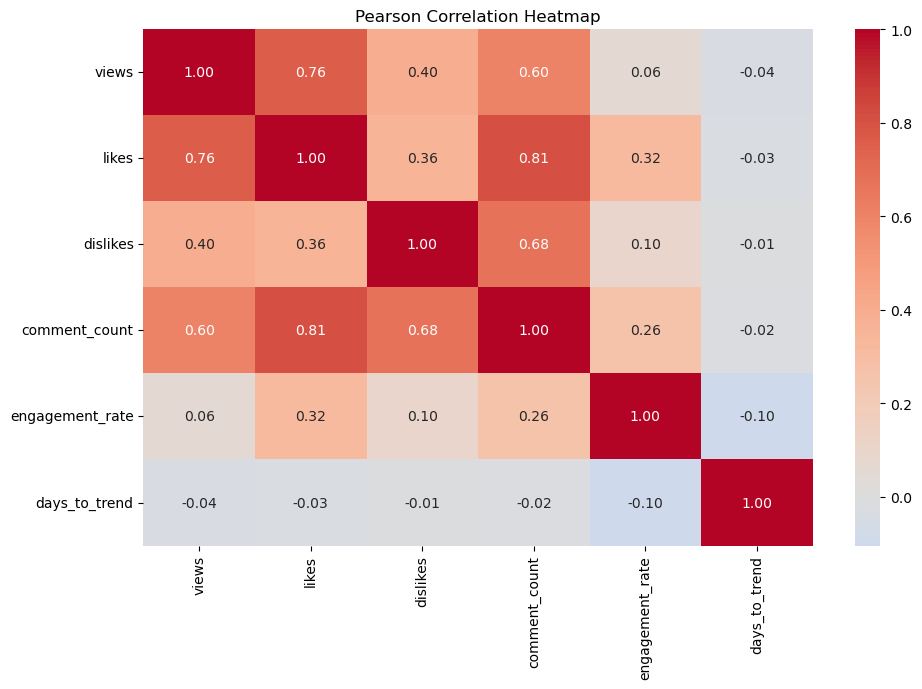

In [37]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

# Vizual 2:

In [60]:
avg_views_category = (df_clean.groupby("category_name")["views"].mean().sort_values(ascending=False))

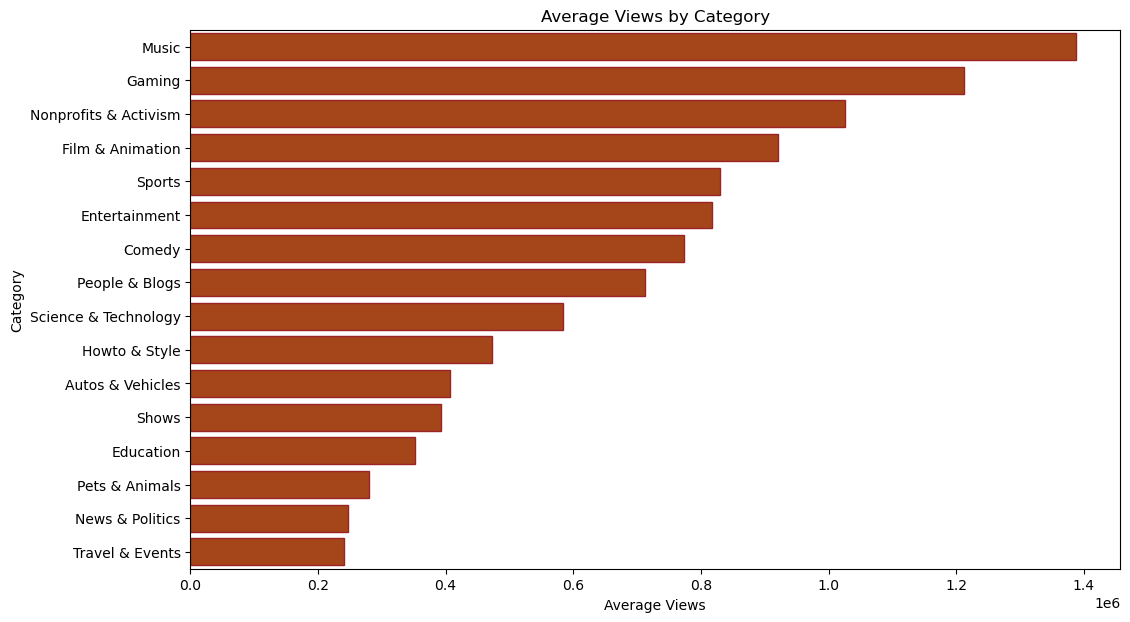

In [61]:
plt.figure(figsize=(12, 7))
sns.barplot( x=avg_views_category.values, y=avg_views_category.index,color='#bb3e03',edgecolor='#9b2226')

plt.title("Average Views by Category")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.show() 

# Vizual 3:

In [58]:
avg_engagement_category = (df_clean .groupby("category_name")["engagement_rate"].mean().sort_values(ascending=False))

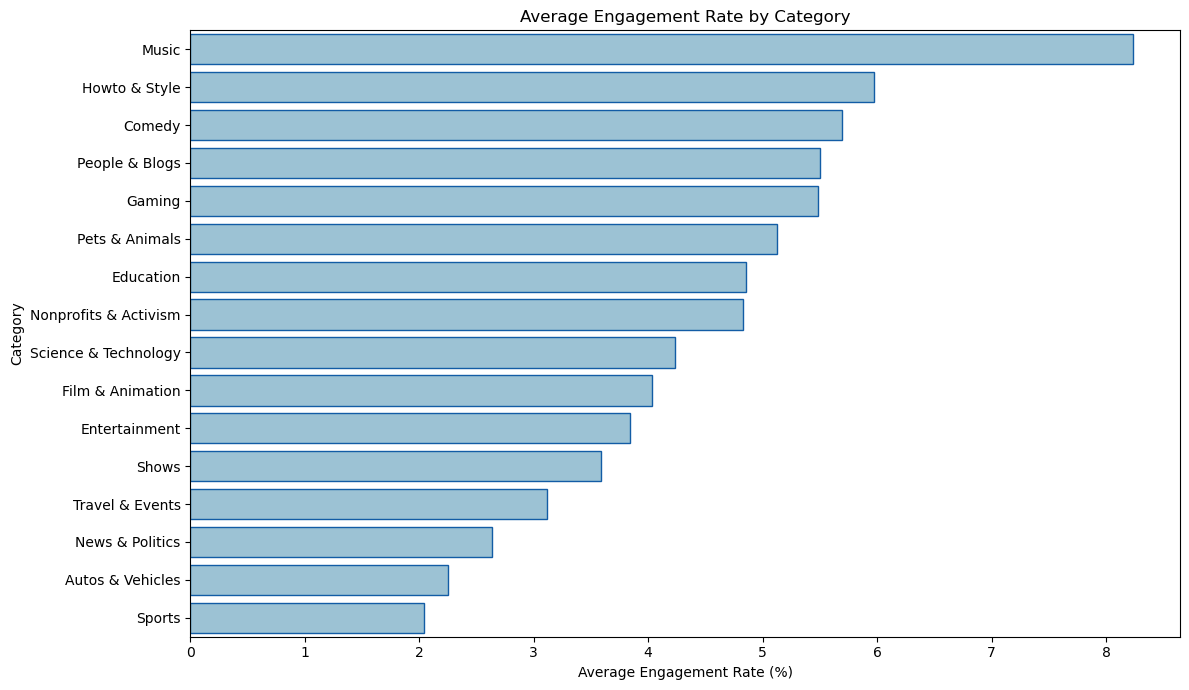

In [59]:
plt.figure(figsize=(12, 7))
sns.barplot( x=avg_engagement_category.values,y=avg_engagement_category.index,color='#92C5DE',edgecolor='#125CA5')

plt.title("Average Engagement Rate by Category")
plt.xlabel("Average Engagement Rate (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Vizual 4: 

In [47]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"]


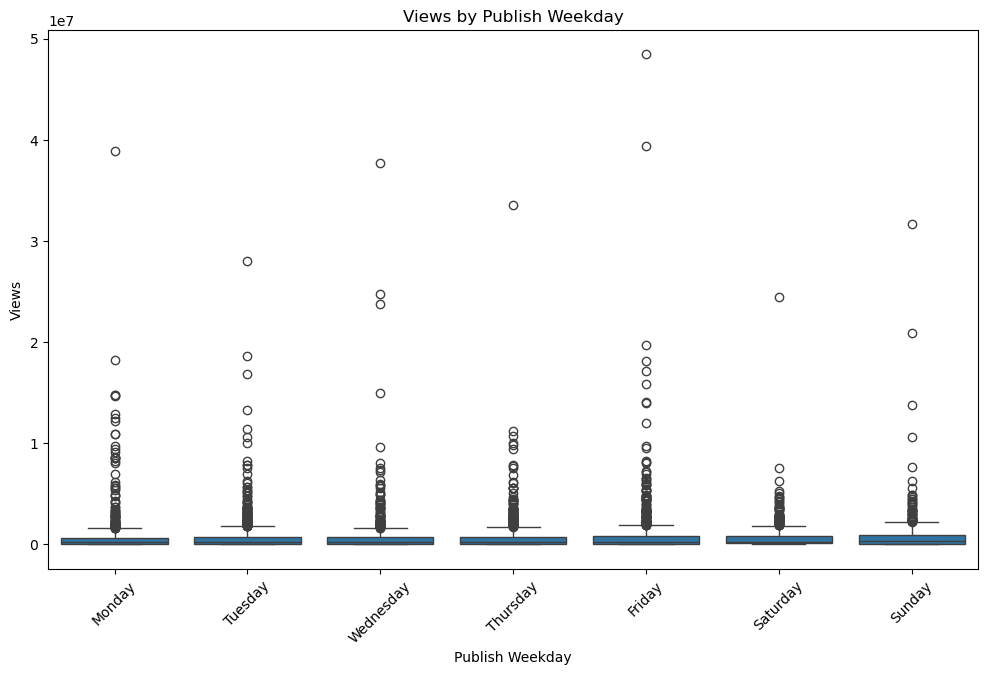

In [48]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_clean, x="publish_weekday", y="views",order=weekday_order)

plt.title("Views by Publish Weekday")
plt.xlabel("Publish Weekday")
plt.ylabel("Views")
plt.xticks(rotation=45)
plt.show()

# Bonus 1:

In [49]:
views_median = df['views'].median()
engagement_median = df['engagement_rate'].median()

passive = df[(df['views'] > views_median) &(df['engagement_rate'] < engagement_median)]

niche = df[(df['views'] < views_median) &(df['engagement_rate'] > engagement_median)]

In [50]:
passive

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name,engagement_rate,like_rate,days_to_trend
39584,-0CMnp02rNY,2018-06-08,Mindy Kaling's Daughter Had the Perfect Reacti...,TheEllenShow,24,2018-06-04 13:00:00+00:00,"ellen|""ellen degeneres""|""the ellen show""|""elle...",705986,8930,277,371,https://i.ytimg.com/vi/-0CMnp02rNY/default.jpg,False,False,False,Ocean's 8 star Mindy Kaling dished on bringing...,NaN,1.356684,1.264898,3.458333
39795,-0CMnp02rNY,2018-06-09,Mindy Kaling's Daughter Had the Perfect Reacti...,TheEllenShow,24,2018-06-04 13:00:00+00:00,"ellen|""ellen degeneres""|""the ellen show""|""elle...",754273,9395,303,383,https://i.ytimg.com/vi/-0CMnp02rNY/default.jpg,False,False,False,Ocean's 8 star Mindy Kaling dished on bringing...,NaN,1.336519,1.245570,4.458333
40007,-0CMnp02rNY,2018-06-10,Mindy Kaling's Daughter Had the Perfect Reacti...,TheEllenShow,24,2018-06-04 13:00:00+00:00,"ellen|""ellen degeneres""|""the ellen show""|""elle...",792613,9720,330,413,https://i.ytimg.com/vi/-0CMnp02rNY/default.jpg,False,False,False,Ocean's 8 star Mindy Kaling dished on bringing...,NaN,1.320064,1.226324,5.458333
40208,-0CMnp02rNY,2018-06-11,Mindy Kaling's Daughter Had the Perfect Reacti...,TheEllenShow,24,2018-06-04 13:00:00+00:00,"ellen|""ellen degeneres""|""the ellen show""|""elle...",800359,9773,332,423,https://i.ytimg.com/vi/-0CMnp02rNY/default.jpg,False,False,False,Ocean's 8 star Mindy Kaling dished on bringing...,NaN,1.315410,1.221077,6.458333
31553,-1Hm41N0dUs,2018-04-29,Cast of Avengers: Infinity War Draws Their Cha...,Jimmy Kimmel Live,23,2018-04-27 07:30:02+00:00,"jimmy|""jimmy kimmel""|""jimmy kimmel live""|""late...",1566807,32752,393,1490,https://i.ytimg.com/vi/-1Hm41N0dUs/default.jpg,False,False,False,"Benedict Cumberbatch, Don Cheadle, Elizabeth O...",NaN,2.210547,2.090366,1.687477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36143,zxwfDlhJIpw,2018-05-21,kanye west / charlamagne interview,Kanye West,22,2018-05-01 15:57:06+00:00,"Kanye West|""YEEZY""|""Kanye""|""Charlamagne""|""The ...",8388846,166055,19395,48389,https://i.ytimg.com/vi/zxwfDlhJIpw/default.jpg,False,False,False,NaN,NaN,2.787499,1.979474,19.335347
36339,zxwfDlhJIpw,2018-05-22,kanye west / charlamagne interview,Kanye West,22,2018-05-01 15:57:06+00:00,"Kanye West|""YEEZY""|""Kanye""|""Charlamagne""|""The ...",8403866,166188,19412,48420,https://i.ytimg.com/vi/zxwfDlhJIpw/default.jpg,False,False,False,NaN,NaN,2.784671,1.977518,20.335347
36540,zxwfDlhJIpw,2018-05-23,kanye west / charlamagne interview,Kanye West,22,2018-05-01 15:57:06+00:00,"Kanye West|""YEEZY""|""Kanye""|""Charlamagne""|""The ...",8418654,166297,19426,48401,https://i.ytimg.com/vi/zxwfDlhJIpw/default.jpg,False,False,False,NaN,NaN,2.781015,1.975340,21.335347
36742,zxwfDlhJIpw,2018-05-24,kanye west / charlamagne interview,Kanye West,22,2018-05-01 15:57:06+00:00,"Kanye West|""YEEZY""|""Kanye""|""Charlamagne""|""The ...",8431178,166420,19445,48409,https://i.ytimg.com/vi/zxwfDlhJIpw/default.jpg,False,False,False,NaN,NaN,2.778663,1.973864,22.335347


In [51]:
niche

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name,engagement_rate,like_rate,days_to_trend
3019,-1yT-K3c6YI,2017-11-29,YOUTUBER QUIZ + TRUTH OR DARE W/ THE MERRELL T...,Molly Burke,22,2017-11-28 18:30:43+00:00,"youtube quiz|""youtuber quiz""|""truth or dare""|""...",129360,5214,108,516,https://i.ytimg.com/vi/-1yT-K3c6YI/default.jpg,False,False,False,Check out the video we did on the Merrell Twin...,NaN,4.512987,4.030612,0.228669
3237,-1yT-K3c6YI,2017-11-30,YOUTUBER QUIZ + TRUTH OR DARE W/ THE MERRELL T...,Molly Burke,22,2017-11-28 18:30:43+00:00,"youtube quiz|""youtuber quiz""|""truth or dare""|""...",198315,6950,184,735,https://i.ytimg.com/vi/-1yT-K3c6YI/default.jpg,False,False,False,Check out the video we did on the Merrell Twin...,NaN,3.967930,3.504526,1.228669
3483,-1yT-K3c6YI,2017-12-01,YOUTUBER QUIZ + TRUTH OR DARE W/ THE MERRELL T...,Molly Burke,22,2017-11-28 18:30:43+00:00,"youtube quiz|""youtuber quiz""|""truth or dare""|""...",218227,7407,209,831,https://i.ytimg.com/vi/-1yT-K3c6YI/default.jpg,False,False,False,Check out the video we did on the Merrell Twin...,NaN,3.870740,3.394172,2.228669
3711,-1yT-K3c6YI,2017-12-02,YOUTUBER QUIZ + TRUTH OR DARE W/ THE MERRELL T...,Molly Burke,22,2017-11-28 18:30:43+00:00,"youtube quiz|""youtuber quiz""|""truth or dare""|""...",231341,7734,212,846,https://i.ytimg.com/vi/-1yT-K3c6YI/default.jpg,False,False,False,Check out the video we did on the Merrell Twin...,NaN,3.800450,3.343117,3.228669
7220,-2b4qSoMnKE,2017-12-20,Ex-UFO program chief: We may not be alone,CNN,25,2017-12-19 20:46:33+00:00,"latest News|""Happening Now""|""CNN""|""luis elizon...",84744,1444,199,1610,https://i.ytimg.com/vi/-2b4qSoMnKE/default.jpg,False,False,False,"Luis Elizondo, a former military intelligence ...",NaN,3.838620,1.703955,0.134340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27507,zwEn-ambXLw,2018-04-02,This Is Me - Cover by Shoshana Bean Featuring ...,Shoshana Bean,10,2018-03-22 08:30:07+00:00,"travis wall|""shoshana bean""|""greatest showman""...",210328,7453,123,310,https://i.ytimg.com/vi/zwEn-ambXLw/default.jpg,False,False,False,I was lucky enough to lay the original demo fo...,NaN,3.749382,3.543513,10.645752
27719,zwEn-ambXLw,2018-04-03,This Is Me - Cover by Shoshana Bean Featuring ...,Shoshana Bean,10,2018-03-22 08:30:07+00:00,"travis wall|""shoshana bean""|""greatest showman""...",220426,7778,132,310,https://i.ytimg.com/vi/zwEn-ambXLw/default.jpg,False,False,False,I was lucky enough to lay the original demo fo...,NaN,3.729143,3.528622,11.645752
27927,zwEn-ambXLw,2018-04-04,This Is Me - Cover by Shoshana Bean Featuring ...,Shoshana Bean,10,2018-03-22 08:30:07+00:00,"travis wall|""shoshana bean""|""greatest showman""...",227543,8014,136,316,https://i.ytimg.com/vi/zwEn-ambXLw/default.jpg,False,False,False,I was lucky enough to lay the original demo fo...,NaN,3.720615,3.521972,12.645752
28131,zwEn-ambXLw,2018-04-05,This Is Me - Cover by Shoshana Bean Featuring ...,Shoshana Bean,10,2018-03-22 08:30:07+00:00,"travis wall|""shoshana bean""|""greatest showman""...",234917,8255,143,316,https://i.ytimg.com/vi/zwEn-ambXLw/default.jpg,False,False,False,I was lucky enough to lay the original demo fo...,NaN,3.709395,3.514007,13.645752


# Bonus 2:

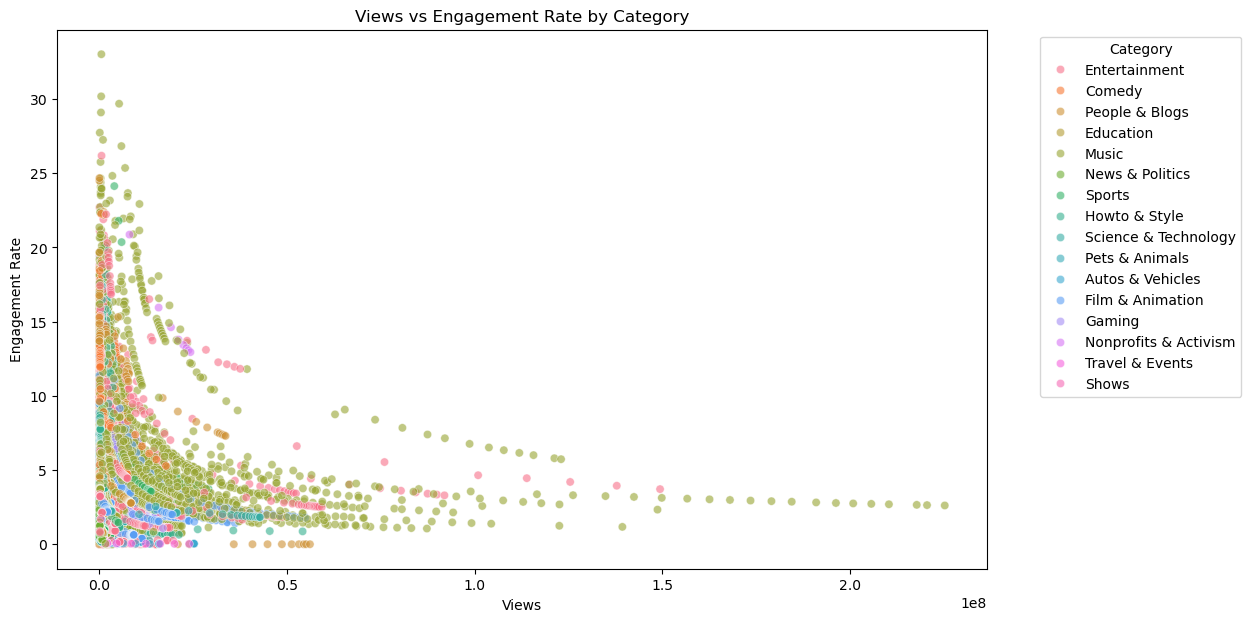

In [57]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='views',
    y='engagement_rate',
    hue='category_name',
    alpha=0.6)

plt.title('Views vs Engagement Rate by Category')
plt.xlabel('Views')
plt.ylabel('Engagement Rate')
plt.legend( title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()